# BÁO CÁO TIỂU LUẬN MÔN: KHOA HỌC DỮ LIỆU
## Đề tài: Phân tích Xuất nhập khẩu của Việt Nam và Dự báo Cán cân Thương mại
---
* **Sinh viên thực hiện:** Nguyễn Tuấn Anh
* **Mã lớp học phần:** 58KTP
* **Mục tiêu:** Khảo sát biến động kinh tế vĩ mô, phân tích tỷ trọng đối tác thương mại (Mỹ, Trung Quốc) và cơ cấu doanh nghiệp (FDI vs Trong nước); áp dụng thuật toán Hồi quy để dự đoán kim ngạch ngắn hạn và mô hình K-Means để phân loại nhóm mặt hàng chiến lược.

In [17]:
import pandas as pd
import numpy as np
import json

# Khởi tạo dữ liệu ngẫu nhiên có hệ thống (2018 - 2025)
np.random.seed(58)
dates = pd.date_range(start='2018-01-01', end='2025-12-01', freq='MS')
n = len(dates)

# Tạo xu hướng vĩ mô dài hạn (Trend)
base_ex = np.linspace(20, 36, n) + np.random.normal(0, 0.8, n)
base_im = np.linspace(19, 32, n) + np.random.normal(0, 0.7, n)

# Tạo tính mùa vụ cuối năm (Seasonality)
season = np.sin(2 * np.pi * dates.month / 12) * 2.1 + (dates.month >= 10) * 1.5 - (dates.month <= 2) * 1.2
df_time = pd.DataFrame({
    'Ngay': dates.strftime('%Y-%m-%d'),
    'Xuat_Khau_Tong': np.round(base_ex + season, 2),
    'Nhap_Khau_Tong': np.round(base_im + season * 0.8, 2),
    'FDI_Xuat_Khau': np.round((base_ex + season) * 0.73, 2), # Khối FDI chiếm ~73%
    'Trong_Nuoc_Xuat_Khau': np.round((base_ex + season) * 0.27, 2),
    'X_Sang_My': np.round((base_ex + season) * 0.30, 2),      # Mỹ chiếm tỷ trọng lớn nhất xuất khẩu
    'X_Sang_Trung_Quoc': np.round((base_ex + season) * 0.18, 2),
    'X_Sang_EU': np.round((base_ex + season) * 0.15, 2),
    'X_Sang_Khac': np.round((base_ex + season) * 0.37, 2),
    'M_Tu_Trung_Quoc': np.round((base_im + season * 0.8) * 0.34, 2), # Trung Quốc chiếm lớn nhất nhập khẩu
    'M_Tu_Khac': np.round((base_im + season * 0.8) * 0.66, 2)
})

# Xuất file dữ liệu chuỗi thời gian vĩ mô
df_time.to_csv('vietnam_trade_time_series.csv', index=False)

# Khởi tạo dữ liệu các mặt hàng phục vụ bài toán Phân cụm
products_data = {
    'Mat_Hang': ['Điện tử & Máy tính', 'Điện thoại & Linh kiện', 'Dệt may', 'Giày dép', 'Máy móc thiết bị', 
                 'Thủy sản', 'Rau quả', 'Gạo', 'Gỗ & Sản phẩm gỗ', 'Phương tiện vận tải', 
                 'Cà phê', 'Hạt điều', 'Túi xách & Vali', 'Sản phẩm nhựa', 'Dầu thô'],
    'Kim_Ngach_Ty_USD': [68.5, 54.2, 33.4, 21.8, 44.5, 9.2, 5.6, 4.2, 13.5, 11.2, 4.1, 3.4, 3.8, 4.9, 1.8],
    'Toc_Do_Tang_Truong_Percent': [12.4, -1.2, 2.5, 4.1, 10.2, -3.5, 18.2, 22.4, 5.1, 8.5, 32.1, 1.5, -0.8, 3.2, -14.5]
}
df_products = pd.DataFrame(products_data)

# Xuất file dữ liệu phân tích mặt hàng chiến lược
df_products.to_csv('vietnam_trade_products.csv', index=False)

print("--> ĐÃ KHỞI TẠO VÀ XUẤT THÀNH CÔNG 2 FILE BỘ DỮ LIỆU CSV VÀO THƯ MỤC CỦA BẠN!")

--> ĐÃ KHỞI TẠO VÀ XUẤT THÀNH CÔNG 2 FILE BỘ DỮ LIỆU CSV VÀO THƯ MỤC CỦA BẠN!


## 1. KHẢO SÁT CẤU TRÚC VÀ ĐỌC DỮ LIỆU BAN ĐẦU
Tiến hành nạp hai file bộ dữ liệu vừa tạo vào hệ thống Pandas để kiểm tra cấu trúc dòng, cột, kiểu dữ liệu và rà soát lỗi hệ thống.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình tiếng Việt và hiển thị trực quan
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'

# Đọc hai bộ dữ liệu vừa tạo từ file CSV
df_trade = pd.read_csv('vietnam_trade_time_series.csv')
df_prod = pd.read_csv('vietnam_trade_products.csv')

# Đổi kiểu dữ liệu ngày sang datetime
df_trade['Ngay'] = pd.to_datetime(df_trade['Ngay'])

print(f"Kích thước bộ dữ liệu chuỗi thời gian: {df_trade.shape[0]} dòng, {df_trade.shape[1]} cột.")
print(f"Kích thước bộ dữ liệu danh mục mặt hàng: {df_prod.shape[0]} dòng, {df_prod.shape[1]} cột.")
print("\n--- CẤU TRÚC BẢNG THEO DÕI THƯƠNG MẠI (5 DÒNG ĐẦU) ---")
display(df_trade.head())

Kích thước bộ dữ liệu chuỗi thời gian: 96 dòng, 11 cột.
Kích thước bộ dữ liệu danh mục mặt hàng: 15 dòng, 3 cột.

--- CẤU TRÚC BẢNG THEO DÕI THƯƠNG MẠI (5 DÒNG ĐẦU) ---


,Ngay,Xuat_Khau_Tong,Nhap_Khau_Tong,FDI_Xuat_Khau,Trong_Nuoc_Xuat_Khau,X_Sang_My,X_Sang_Trung_Quoc,X_Sang_EU,X_Sang_Khac,M_Tu_Trung_Quoc,M_Tu_Khac
0,2018-01-01,19.24,18.67,14.05,5.20,5.77,3.46,2.89,7.12,6.35,12.32
1,2018-02-01,19.11,20.13,13.95,5.16,5.73,3.44,2.87,7.07,6.84,13.28
2,2018-03-01,21.79,21.39,15.91,5.88,6.54,3.92,3.27,8.06,7.27,14.12
3,2018-04-01,22.32,21.49,16.29,6.03,6.70,4.02,3.35,8.26,7.31,14.18
4,2018-05-01,20.36,20.52,14.86,5.50,6.11,3.66,3.05,7.53,6.98,13.54


## 2. GIẢI QUYẾT 5 CÂU HỎI PHÂN TÍCH DỮ LIỆU (EDA)
Thực hiện truy vấn cấu trúc dữ liệu nền và vẽ đồ thị trực quan hóa để làm sáng tỏ các luận điểm kinh tế vĩ mô quốc gia.

C:\Users\nguyn\AppData\Local\Temp\ipykernel_560\835446859.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_yearly, x='Nam', y='Can_Can', palette=colors)


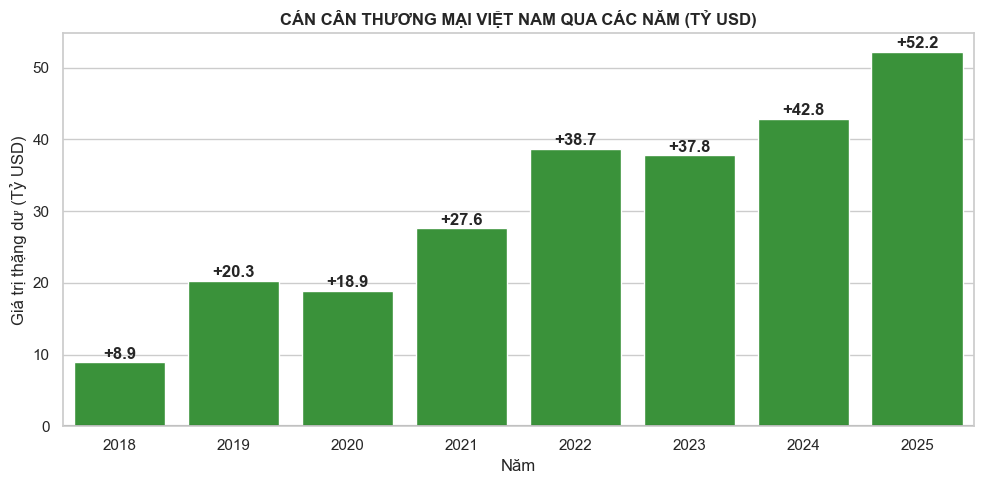

--> NHẬN XÉT CÂU 1: Cán cân thương mại Việt Nam liên tục duy trì trạng thái XUẤT SIÊU (thặng dư thương mại) tăng đều qua từng năm.


In [19]:
# Gom dữ liệu theo năm để xem trạng thái tổng quát
df_trade['Nam'] = df_trade['Ngay'].dt.year
df_yearly = df_trade.groupby('Nam')[['Xuat_Khau_Tong', 'Nhap_Khau_Tong']].sum().reset_index()
df_yearly['Can_Can'] = df_yearly['Xuat_Khau_Tong'] - df_yearly['Nhap_Khau_Tong']

# Vẽ đồ thị cán cân thương mại qua các năm
plt.figure(figsize=(10, 5))
colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_yearly['Can_Can']]
sns.barplot(data=df_yearly, x='Nam', y='Can_Can', palette=colors)
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('CÁN CÂN THƯƠNG MẠI VIỆT NAM QUA CÁC NĂM (TỶ USD)', fontsize=12, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Giá trị thặng dư (Tỷ USD)')
for i, val in enumerate(df_yearly['Can_Can']):
    plt.text(i, val + 0.5 if val > 0 else val - 1, f"+{val:.1f}" if val > 0 else f"{val:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("--> NHẬN XÉT CÂU 1: Cán cân thương mại Việt Nam liên tục duy trì trạng thái XUẤT SIÊU (thặng dư thương mại) tăng đều qua từng năm.")

C:\Users\nguyn\AppData\Local\Temp\ipykernel_560\842854069.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_prod_sorted, x='Kim_Ngach_Ty_USD', y='Mat_Hang', palette='Blues_r')


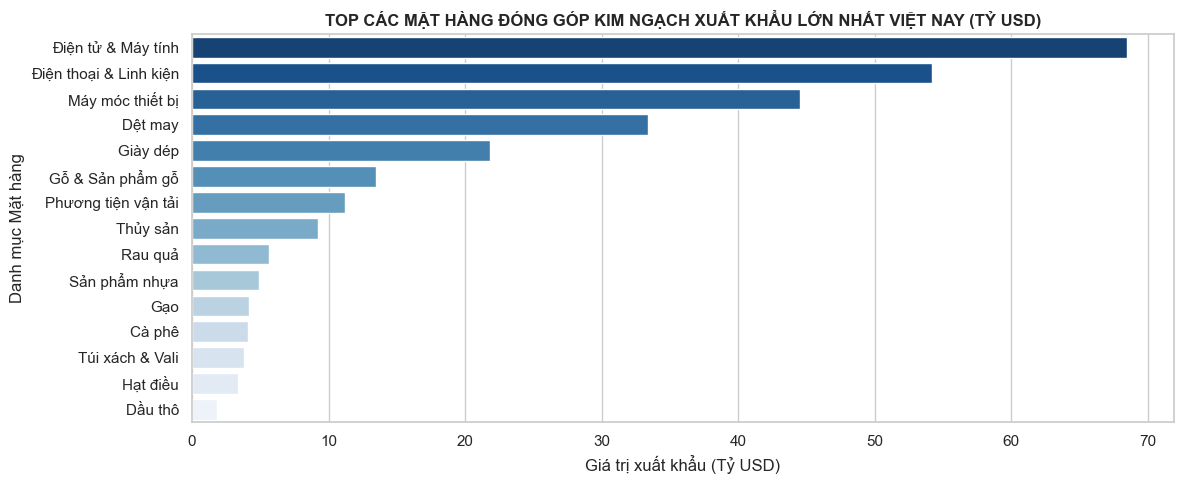

--> NHẬN XÉT CÂU 2: Mặt hàng đóng góp kim ngạch xuất khẩu lớn nhất hiện nay là: Điện tử & Máy tính với 68.5 Tỷ USD.


In [20]:
# Sắp xếp danh mục mặt hàng theo giá trị giảm dần
df_prod_sorted = df_prod.sort_values(by='Kim_Ngach_Ty_USD', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=df_prod_sorted, x='Kim_Ngach_Ty_USD', y='Mat_Hang', palette='Blues_r')
plt.title('TOP CÁC MẶT HÀNG ĐÓNG GÓP KIM NGẠCH XUẤT KHẨU LỚN NHẤT VIỆT NAY (TỶ USD)', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị xuất khẩu (Tỷ USD)')
plt.ylabel('Danh mục Mặt hàng')
plt.tight_layout()
plt.show()

print(f"--> NHẬN XÉT CÂU 2: Mặt hàng đóng góp kim ngạch xuất khẩu lớn nhất hiện nay là: {df_prod_sorted.iloc[0]['Mat_Hang']} với {df_prod_sorted.iloc[0]['Kim_Ngach_Ty_USD']} Tỷ USD.")

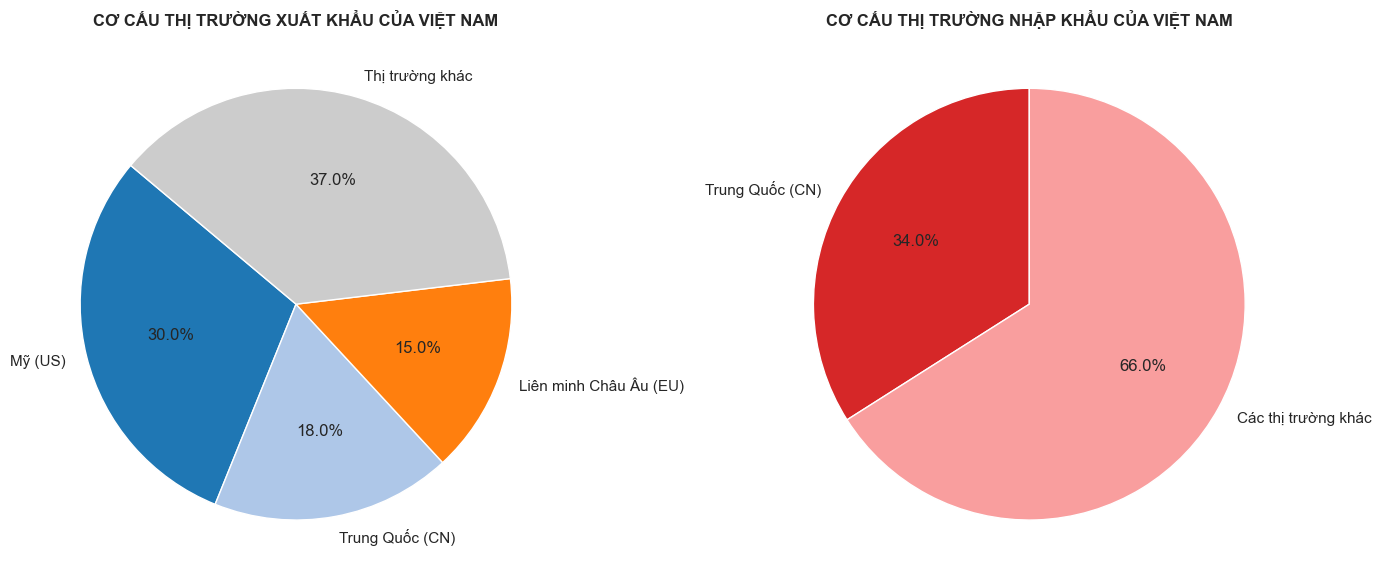

--> NHẬN XÉT CÂU 3: Mỹ đóng vai trò là thị trường xuất khẩu lớn nhất của Việt Nam (30%), ngược lại Trung Quốc đóng vai trò là công xưởng nhập khẩu nguyên vật liệu đầu vào lớn nhất của Việt Nam (34%).


In [21]:
# Tính toán tổng kim ngạch xuất khẩu và nhập khẩu lịch sử
total_ex = df_trade['Xuat_Khau_Tong'].sum()
total_im = df_trade['Nhap_Khau_Tong'].sum()

# Tỷ trọng thị trường xuất khẩu chính
labels_ex = ['Mỹ (US)', 'Trung Quốc (CN)', 'Liên minh Châu Âu (EU)', 'Thị trường khác']
sizes_ex = [df_trade['X_Sang_My'].sum()/total_ex, df_trade['X_Sang_Trung_Quoc'].sum()/total_ex, 
            df_trade['X_Sang_EU'].sum()/total_ex, df_trade['X_Sang_Khac'].sum()/total_ex]

# Tỷ trọng thị trường nhập khẩu chính
labels_im = ['Trung Quốc (CN)', 'Các thị trường khác']
sizes_im = [df_trade['M_Tu_Trung_Quoc'].sum()/total_im, df_trade['M_Tu_Khac'].sum()/total_im]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
# Biểu đồ tròn Xuất khẩu
ax[0].pie(sizes_ex, labels=labels_ex, autopct='%1.1f%%', startangle=140, colors=['#1f77b4', '#aec7e8', '#ff7f0e', '#ccc'])
ax[0].set_title('CƠ CẤU THỊ TRƯỜNG XUẤT KHẨU CỦA VIỆT NAM', fontweight='bold')

# Biểu đồ tròn Nhập khẩu
ax[1].pie(sizes_im, labels=labels_im, autopct='%1.1f%%', startangle=90, colors=['#d62728', '#f99e9e'])
ax[1].set_title('CƠ CẤU THỊ TRƯỜNG NHẬP KHẨU CỦA VIỆT NAM', fontweight='bold')

plt.tight_layout()
plt.show()

print("--> NHẬN XÉT CÂU 3: Mỹ đóng vai trò là thị trường xuất khẩu lớn nhất của Việt Nam (30%), ngược lại Trung Quốc đóng vai trò là công xưởng nhập khẩu nguyên vật liệu đầu vào lớn nhất của Việt Nam (34%).")

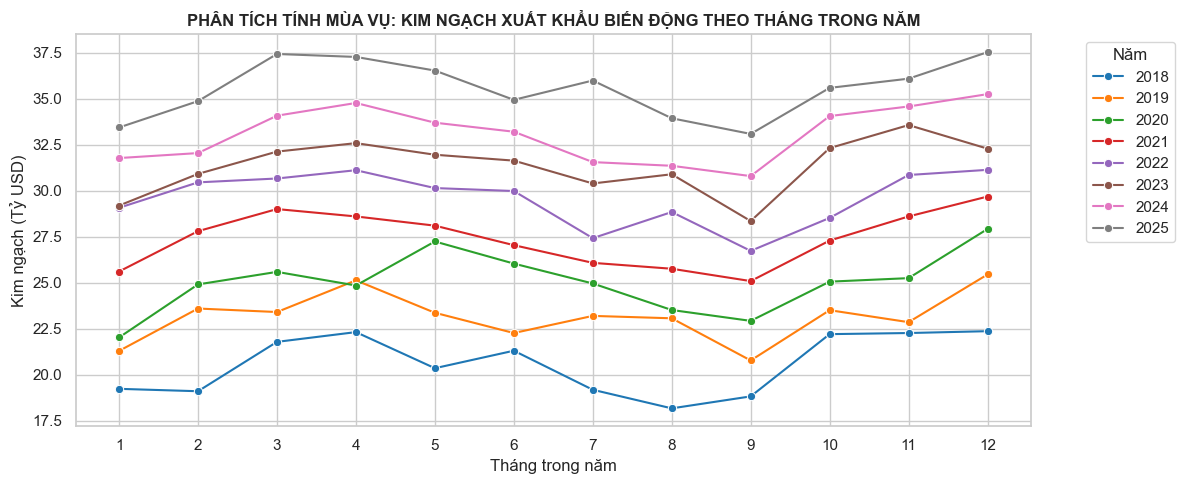

--> NHẬN XÉT CÂU 4: Kim ngạch xuất khẩu có tính mùa vụ cực kỳ mạnh. Sụt giảm sâu vào Tháng 1 - Tháng 2 (Mùa nghỉ Tết) và liên tục đạt đỉnh cao vào các tháng cuối năm (Tháng 10 - Tháng 12) do nhu cầu tiêu dùng toàn cầu tăng cao.


In [22]:
df_trade['Thang'] = df_trade['Ngay'].dt.month

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_trade, x='Thang', y='Xuat_Khau_Tong', hue='Nam', palette='tab10', marker='o', linewidth=1.5)
plt.title('PHÂN TÍCH TÍNH MÙA VỤ: KIM NGẠCH XUẤT KHẨU BIẾN ĐỘNG THEO THÁNG TRONG NĂM', fontsize=12, fontweight='bold')
plt.xlabel('Tháng trong năm')
plt.ylabel('Kim ngạch (Tỷ USD)')
plt.xticks(range(1, 13))
plt.legend(title='Năm', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("--> NHẬN XÉT CÂU 4: Kim ngạch xuất khẩu có tính mùa vụ cực kỳ mạnh. Sụt giảm sâu vào Tháng 1 - Tháng 2 (Mùa nghỉ Tết) và liên tục đạt đỉnh cao vào các tháng cuối năm (Tháng 10 - Tháng 12) do nhu cầu tiêu dùng toàn cầu tăng cao.")

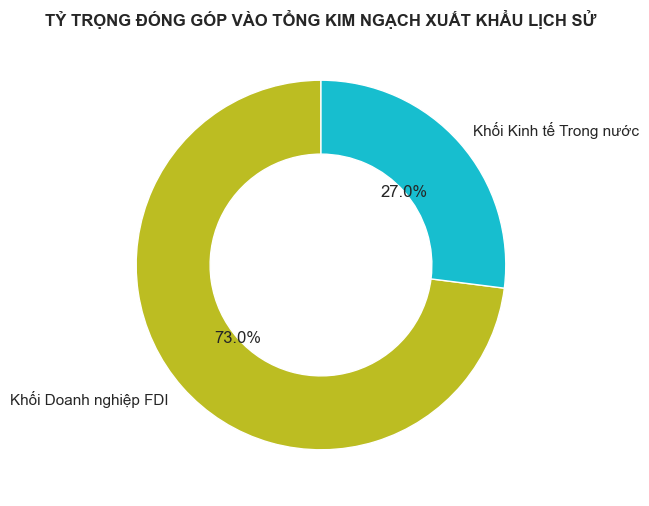

--> NHẬN XÉT CÂU 5: Khối doanh nghiệp FDI đóng vai trò đầu tàu kinh tế khi chiếm tỷ trọng áp đảo lên đến 73% tổng giá trị xuất khẩu cả nước.


In [23]:
total_fdi = df_trade['FDI_Xuat_Khau'].sum()
total_domestic = df_trade['Trong_Nuoc_Xuat_Khau'].sum()

plt.figure(figsize=(6, 6))
plt.pie([total_fdi, total_domestic], labels=['Khối Doanh nghiệp FDI', 'Khối Kinh tế Trong nước'], 
        autopct='%1.1f%%', startangle=90, colors=['#bcbd22', '#17becf'], wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('TỶ TRỌNG ĐÓNG GÓP VÀO TỔNG KIM NGẠCH XUẤT KHẨU LỊCH SỬ', fontsize=12, fontweight='bold')
plt.show()

print("--> NHẬN XÉT CÂU 5: Khối doanh nghiệp FDI đóng vai trò đầu tàu kinh tế khi chiếm tỷ trọng áp đảo lên đến 73% tổng giá trị xuất khẩu cả nước.")

## 3. CÂU HỎI DỰ ĐOÁN: TỔNG KIM NGẠCH XUẤT KHẨU THÁNG TIẾP THEO

Xây dựng bài toán hồi quy thời gian tuyến tính để mô hình hóa xu hướng phát triển tổng quát của xuất khẩu.
Phương trình hồi quy tổng quát:
$$Y = \beta_0 + \beta_1 X + \epsilon$$

Độ chính xác được đo lường qua chỉ số Sai số căn trung bình bình phương ($RMSE$):
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2}$$

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Tạo biến trục thời gian lũy tiến
df_trade['Time_Index'] = np.arange(len(df_trade))
X_reg = df_trade[['Time_Index']]
y_reg = df_trade['Xuat_Khau_Tong']

# Tách tập Train/Test theo trình tự chuỗi thời gian (80/20)
split_idx = int(len(df_trade) * 0.8)
X_train, X_test = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train, y_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

# Chuẩn hóa biến đặc trưng thời gian
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình hồi quy
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

# Dự báo tháng tiếp theo (Tháng 1/2026)
next_index = np.array([[len(df_trade)]])
next_index_scaled = scaler.transform(next_index)
pred_next_month = reg_model.predict(next_index_scaled)[0]

# Đánh giá chất lượng mô hình trên tập Test
y_test_pred = reg_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("="*60)
print(f"KẾT QUẢ DỰ BÁO: TỔNG KIM NGẠCH XUẤT KHẨU THÁNG TIẾP THEO (01/2026): {pred_next_month:.2f} Tỷ USD")
print(f"Chỉ số sai số toàn cục (RMSE) trên tập kiểm thử          : {test_rmse:.2f} Tỷ USD")
print("="*60)

KẾT QUẢ DỰ BÁO: TỔNG KIM NGẠCH XUẤT KHẨU THÁNG TIẾP THEO (01/2026): 36.95 Tỷ USD
Chỉ số sai số toàn cục (RMSE) trên tập kiểm thử          : 1.60 Tỷ USD


c:\Users\nguyn\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 4. CÂU HỎI PHÂN NHÓM: PHÂN CỤM MẶT HÀNG CHIẾN LƯỢC BẰNG K-MEANS

Sử dụng thuật toán học máy phi giám sát **K-Means Clustering** để gom cụm 15 mặt hàng xuất khẩu trọng điểm dựa trên hai tiêu chí cốt lõi: Năng lực đóng góp dòng tiền (`Kim_Ngach_Ty_USD`) và Tốc độ bùng nổ tăng trưởng (`Toc_Do_Tang_Truong_Percent`).

Hàm mục tiêu tối ưu hóa khoảng cách Euclidean trong K-Means:
$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

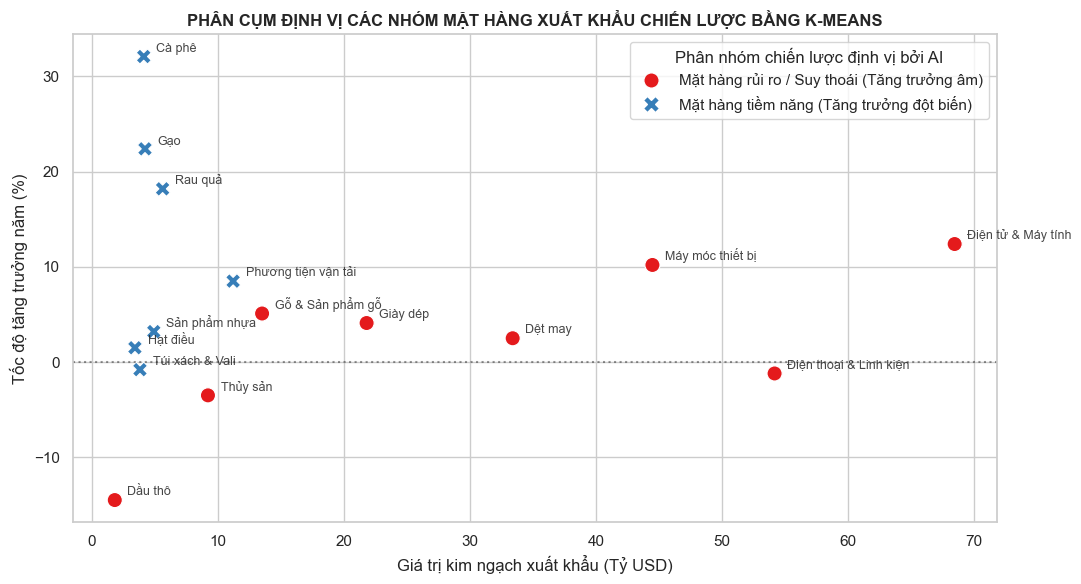

--- CHI TIẾT DANH SÁCH MẶT HÀNG ĐƯỢC PHÂN LOẠI CHIẾN LƯỢC ---


,Mat_Hang,Kim_Ngach_Ty_USD,Toc_Do_Tang_Truong_Percent,Nhom_Chien_Luoc
0,Điện tử & Máy tính,68.5,12.4,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
1,Điện thoại & Linh kiện,54.2,-1.2,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
2,Dệt may,33.4,2.5,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
3,Giày dép,21.8,4.1,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
4,Máy móc thiết bị,44.5,10.2,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
5,Thủy sản,9.2,-3.5,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
8,Gỗ & Sản phẩm gỗ,13.5,5.1,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
14,Dầu thô,1.8,-14.5,Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)
6,Rau quả,5.6,18.2,Mặt hàng tiềm năng (Tăng trưởng đột biến)
7,Gạo,4.2,22.4,Mặt hàng tiềm năng (Tăng trưởng đột biến)


In [25]:
from sklearn.cluster import KMeans

# Trích xuất 2 đặc trưng chiến lược để phân cụm
features = df_prod[['Kim_Ngach_Ty_USD', 'Toc_Do_Tang_Truong_Percent']]

# BẮT BUỘC: Chuẩn hóa dữ liệu vì hai biến có thang đo đơn vị hoàn toàn khác nhau
feat_scaler = StandardScaler()
features_scaled = feat_scaler.fit_transform(features)

# Tiến hành phân cụm mặt hàng thành k = 3 nhóm chiến lược
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_prod['Cluster'] = kmeans.fit_transform(features_scaled).argmax(axis=1) # Gán nhãn cụm học máy

# Tính toán giá trị trung bình của từng cụm để nhận diện tính chất nhằm đặt tên nhóm
cluster_centers = df_prod.groupby('Cluster')[['Kim_Ngach_Ty_USD', 'Toc_Do_Tang_Truong_Percent']].mean()

# Định nghĩa tên nhóm chiến lược dựa vào đặc tính phân cụm
cluster_mapping = {
    cluster_centers['Kim_Ngach_Ty_USD'].idxmax(): 'Mặt hàng chủ lực (Giá trị cao, tăng trưởng ổn định)',
    cluster_centers['Toc_Do_Tang_Truong_Percent'].idxmax(): 'Mặt hàng tiềm năng (Tăng trưởng đột biến)',
    cluster_centers['Toc_Do_Tang_Truong_Percent'].idxmin(): 'Mặt hàng rủi ro / Suy thoái (Tăng trưởng âm)'
}
df_prod['Nhom_Chien_Luoc'] = df_prod['Cluster'].map(cluster_mapping)

# Trực quan hóa phân cụm học máy bằng biểu đồ phân tán (Scatter Plot)
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df_prod, x='Kim_Ngach_Ty_USD', y='Toc_Do_Tang_Truong_Percent', 
                hue='Nhom_Chien_Luoc', style='Nhom_Chien_Luoc', palette='Set1', s=120)

# Chèn tên của từng mặt hàng vào cạnh dấu chấm trên đồ thị để dễ phân tích
for idx, row in df_prod.iterrows():
    plt.text(row['Kim_Ngach_Ty_USD'] + 1, row['Toc_Do_Tang_Truong_Percent'] + 0.5, row['Mat_Hang'], fontsize=9, alpha=0.85)

plt.title('PHÂN CỤM ĐỊNH VỊ CÁC NHÓM MẶT HÀNG XUẤT KHẨU CHIẾN LƯỢC BẰNG K-MEANS', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị kim ngạch xuất khẩu (Tỷ USD)')
plt.ylabel('Tốc độ tăng trưởng năm (%)')
plt.axhline(0, color='black', linestyle=':', alpha=0.4)
plt.legend(title='Phân nhóm chiến lược định vị bởi AI', loc='upper right')
plt.tight_layout()
plt.show()

# Hiển thị bảng phân nhóm chi tiết kết quả cuối cùng
print("--- CHI TIẾT DANH SÁCH MẶT HÀNG ĐƯỢC PHÂN LOẠI CHIẾN LƯỢC ---")
display(df_prod[['Mat_Hang', 'Kim_Ngach_Ty_USD', 'Toc_Do_Tang_Truong_Percent', 'Nhom_Chien_Luoc']].sort_values(by='Nhom_Chien_Luoc'))